<a href="https://colab.research.google.com/github/Aubreylikangala/Financial-Engineering-projects/blob/main/Random_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                         QuantReg Regression Results                          
Dep. Variable:             CDX_HY_ret   Pseudo R-squared:               0.1736
Model:                       QuantReg   Bandwidth:                    0.001563
Method:                 Least Squares   Sparsity:                      0.04476
Date:                Mon, 03 Nov 2025   No. Observations:                 2455
Time:                        11:40:48   Df Residuals:                     2451
                                        Df Model:                            3
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0023      0.001      2.470      0.014       0.000       0.004
VIX             -0.0005   4.94e-05     -9.664      0.000      -0.001      -0.000
TED              0.0002      0.000      1.160      0.246      -0.000       0.000
rolling_corr    -0.0035      0.001     -4.

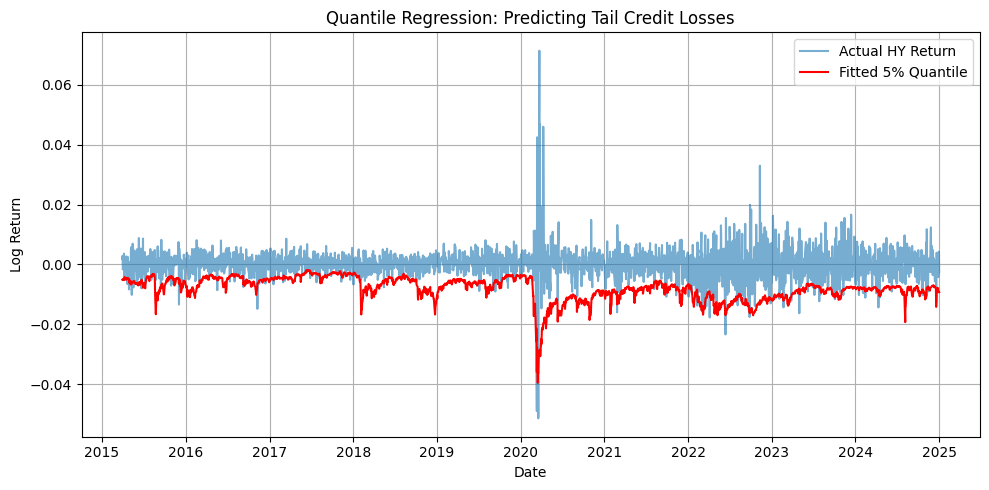

In [ ]:
# STEP 1: Install required packages
!pip install yfinance statsmodels --quiet

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# STEP 3: Download credit ETF prices (LQD = Investment Grade, HYG = High Yield)
etf_data = yf.download(['LQD', 'HYG'], start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']

# STEP 4: Calculate daily log returns
returns = np.log(etf_data).diff().dropna()
returns.columns = ['CDX_IG_ret', 'CDX_HY_ret']

# STEP 5: Compute 60-day rolling correlation between CDX IG and HY
returns['rolling_corr'] = returns['CDX_IG_ret'].rolling(window=60).corr(returns['CDX_HY_ret'])

# STEP 6: Download VIX and IRX (13-week T-bill rate)
vix_series = yf.download('^VIX', start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
irx_series = yf.download('^IRX', start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']

# STEP 7: Create TED spread proxy using IRX (assume fixed unsecured rate of 2.5%)
ted_series = 0.025 - irx_series

# STEP 8: Combine macro indicators and rename columns to match regression formula
macro = pd.concat([vix_series, ted_series], axis=1)
macro.columns = ['VIX', 'TED']
macro = macro.dropna()

# STEP 9: Merge macro indicators with returns
df = returns.join(macro, how='inner').dropna()

# STEP 10: Run quantile regression (5% tail)
model = smf.quantreg('CDX_HY_ret ~ VIX + TED + rolling_corr', df)
res = model.fit(q=0.05)

# STEP 11: Display regression summary
print(res.summary())

# STEP 12: Plot actual vs fitted 5% quantile
df['fitted_q'] = res.predict(df)
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['CDX_HY_ret'], label='Actual HY Return', alpha=0.6)
plt.plot(df.index, df['fitted_q'], label='Fitted 5% Quantile', color='red')
plt.title('Quantile Regression: Predicting Tail Credit Losses')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# STEP 1: Install required packages
!pip install yfinance arch statsmodels --quiet

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt

# STEP 3: Download credit ETF prices (LQD = Investment Grade, HYG = High Yield)
etf_data = yf.download(['LQD', 'HYG'], start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
returns = np.log(etf_data).diff().dropna()
returns.columns = ['CDX_IG_ret', 'CDX_HY_ret']

# STEP 4: Download IRX (13-week T-bill rate) and extract 'Close' as Series
irx_data = yf.download('^IRX', start='2015-01-01', end='2025-01-01', auto_adjust=True)
irx_series = irx_data['Close']

# STEP 5: Create TED spread proxy (assume fixed unsecured rate of 2.5%)
ted_series = pd.Series(0.025, index=irx_series.index) - irx_series
ted_series.name = 'TED'

# STEP 6: Merge TED spread with returns
df = returns.join(ted_series, how='inner').dropna()

# STEP 7: Estimate GARCH(1,1) for CDX IG and HY returns
ig_model = arch_model(df['CDX_IG_ret'] * 100, vol='Garch', p=1, q=1)
hy_model = arch_model(df['CDX_HY_ret'] * 100, vol='Garch', p=1, q=1)

ig_res = ig_model.fit(disp='off')
hy_res = hy_model.fit(disp='off')

# STEP 8: Add conditional volatilities to DataFrame
df['IG_vol'] = ig_res.conditional_volatility
df['HY_vol'] = hy_res.conditional_volatility

# STEP 9: Compute rolling correlation as a DCC proxy
df['rolling_corr'] = df['CDX_IG_ret'].rolling(window=60).corr(df['CDX_HY_ret'])

# STEP 10: Define regimes based on TED spread (above/below median)
df['regime'] = (df['TED'] > df['TED'].median()).astype(int)

# STEP 11: Plot volatility and regime switching
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['IG_vol'], label='IG Volatility', alpha=0.7)
plt.plot(df.index, df['HY_vol'], label='HY Volatility', alpha=0.7)
plt.fill_between(df.index, 0, 1, where=df['regime']==1, color='red', alpha=0.1,
                 transform=plt.gca().get_xaxis_transform(), label='High TED Regime')
plt.title('Volatility and Regime Switching via TED Spread')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


ValueError: first_obs and last_obs produce an empty array.

In [ ]:
# STEP 1: Install required packages
!pip install yfinance arch statsmodels --quiet

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt

# STEP 3: Download credit ETF prices (LQD = Investment Grade, HYG = High Yield)
etf_data = yf.download(['LQD', 'HYG'], start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
returns = np.log(etf_data).diff().dropna()
returns.columns = ['CDX_IG_ret', 'CDX_HY_ret']

# STEP 4: Download IRX (13-week T-bill rate)
irx_data = yf.download('^IRX', start='2015-01-01', end='2025-01-01', auto_adjust=True)
irx_series = irx_data['Close']

# STEP 5: Create TED spread proxy (assume fixed unsecured rate of 2.5%)
ted_series = pd.Series(0.025, index=irx_series.index) - irx_series
ted_series.name = 'TED'

# STEP 6: Merge TED spread with returns
df = returns.join(ted_series, how='inner').dropna()

# ✅ STEP 7: Ensure GARCH input is valid
ig_input = df['CDX_IG_ret'] * 100
hy_input = df['CDX_HY_ret'] * 100

if ig_input.dropna().empty or hy_input.dropna().empty:
    raise ValueError("GARCH input series is empty. Check data merging and availability.")

# STEP 8: Estimate GARCH(1,1) for CDX IG and HY returns
ig_model = arch_model(ig_input, vol='Garch', p=1, q=1)
hy_model = arch_model(hy_input, vol='Garch', p=1, q=1)

ig_res = ig_model.fit(disp='off')
hy_res = hy_model.fit(disp='off')

# STEP 9: Add conditional volatilities to DataFrame
df['IG_vol'] = ig_res.conditional_volatility
df['HY_vol'] = hy_res.conditional_volatility

# STEP 10: Compute rolling correlation as a DCC proxy
df['rolling_corr'] = df['CDX_IG_ret'].rolling(window=60).corr(df['CDX_HY_ret'])

# STEP 11: Define regimes based on TED spread (above/below median)
df['regime'] = (df['TED'] > df['TED'].median()).astype(int)

# STEP 12: Plot volatility and regime switching
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['IG_vol'], label='IG Volatility', alpha=0.7)
plt.plot(df.index, df['HY_vol'], label='HY Volatility', alpha=0.7)
plt.fill_between(df.index, 0, 1, where=df['regime']==1, color='red', alpha=0.1,
                 transform=plt.gca().get_xaxis_transform(), label='High TED Regime')
plt.title('Volatility and Regime Switching via TED Spread')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


ValueError: GARCH input series is empty. Check data merging and availability.

In [ ]:
# STEP 1: Install required packages
!pip install yfinance arch statsmodels --quiet

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt

# STEP 3: Download credit ETF prices
etf_data = yf.download(['LQD', 'HYG'], start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
print("ETF data rows:", len(etf_data))

returns = np.log(etf_data).diff().dropna()
returns.columns = ['CDX_IG_ret', 'CDX_HY_ret']
print("Returns rows:", len(returns))

# STEP 4: Download IRX and compute TED spread
irx_data = yf.download('^IRX', start='2015-01-01', end='2025-01-01', auto_adjust=True)
print("IRX data rows:", len(irx_data))

irx_series = irx_data['Close']
ted_series = pd.Series(0.025, index=irx_series.index) - irx_series
ted_series.name = 'TED'
print("TED series rows:", len(ted_series))

# STEP 5: Align indexes and merge
common_index = returns.index.intersection(ted_series.index)
returns = returns.loc[common_index]
ted_series = ted_series.loc[common_index]
df = returns.copy()
df['TED'] = ted_series
print("Merged df rows:", len(df))

# STEP 6: Check for empty input
ig_input = df['CDX_IG_ret'] * 100
hy_input = df['CDX_HY_ret'] * 100

if ig_input.dropna().empty or hy_input.dropna().empty:
    print("IG input empty:", ig_input.dropna().empty)
    print("HY input empty:", hy_input.dropna().empty)
    raise ValueError("GARCH input series is empty. Check data merging and availability.")

# STEP 7: Fit GARCH models
ig_model = arch_model(ig_input, vol='Garch', p=1, q=1)
hy_model = arch_model(hy_input, vol='Garch', p=1, q=1)

ig_res = ig_model.fit(disp='off')
hy_res = hy_model.fit(disp='off')

# STEP 8: Add volatilities
df['IG_vol'] = ig_res.conditional_volatility
df['HY_vol'] = hy_res.conditional_volatility

# STEP 9: Rolling correlation
df['rolling_corr'] = df['CDX_IG_ret'].rolling(window=60).corr(df['CDX_HY_ret'])

# STEP 10: Regime classification
df['regime'] = (df['TED'] > df['TED'].median()).astype(int)

# STEP 11: Plot
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['IG_vol'], label='IG Volatility', alpha=0.7)
plt.plot(df.index, df['HY_vol'], label='HY Volatility', alpha=0.7)
plt.fill_between(df.index, 0, 1, where=df['regime']==1, color='red', alpha=0.1,
                 transform=plt.gca().get_xaxis_transform(), label='High TED Regime')
plt.title('Volatility and Regime Switching via TED Spread')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed

ETF data rows: 2516
Returns rows: 2515
IRX data rows: 2515
TED series rows: 2515


ValueError: Cannot set a DataFrame with multiple columns to the single column TED

In [ ]:
# STEP 1: Install required packages
!pip install yfinance arch statsmodels --quiet

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt

# STEP 3: Download credit ETF prices (LQD = Investment Grade, HYG = High Yield)
etf_data = yf.download(['LQD', 'HYG'], start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
print("ETF data rows:", len(etf_data))

returns = np.log(etf_data).diff().dropna()
returns.columns = ['CDX_IG_ret', 'CDX_HY_ret']
print("Returns rows:", len(returns))

# STEP 4: Download IRX (13-week T-bill rate)
irx_data = yf.download('^IRX', start='2015-01-01', end='2025-01-01', auto_adjust=True)
print("IRX data rows:", len(irx_data))

irx_series = irx_data['Close']

# STEP 5: Create TED spread proxy (assume fixed unsecured rate of 2.5%)
ted_series = pd.Series(0.025, index=irx_series.index) - irx_series
ted_series.name = 'TED'
print("TED series rows:", len(ted_series))

# STEP 6: Align indexes and merge
common_index = returns.index.intersection(ted_series.index)
returns = returns.loc[common_index]
ted_series = ted_series.loc[common_index]
df = returns.copy()
df['TED'] = ted_series
print("Merged df rows:", len(df))

# STEP 7: Check for empty input
ig_input = df['CDX_IG_ret'] * 100
hy_input = df['CDX_HY_ret'] * 100

if ig_input.dropna().empty or hy_input.dropna().empty:
    print("IG input empty:", ig_input.dropna().empty)
    print("HY input empty:", hy_input.dropna().empty)
    raise ValueError("GARCH input series is empty. Check data merging and availability.")

# STEP 8: Fit GARCH models
ig_model = arch_model(ig_input, vol='Garch', p=1, q=1)
hy_model = arch_model(hy_input, vol='Garch', p=1, q=1)

ig_res = ig_model.fit(disp='off')
hy_res = hy_model.fit(disp='off')

# STEP 9: Add volatilities
df['IG_vol'] = ig_res.conditional_volatility
df['HY_vol'] = hy_res.conditional_volatility

# STEP 10: Rolling correlation
df['rolling_corr'] = df['CDX_IG_ret'].rolling(window=60).corr(df['CDX_HY_ret'])

# STEP 11: Regime classification
df['regime'] = (df['TED'] > df['TED'].median()).astype(int)

# STEP 12: Plot
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['IG_vol'], label='IG Volatility', alpha=0.7)
plt.plot(df.index, df['HY_vol'], label='HY Volatility', alpha=0.7)
plt.fill_between(df.index, 0, 1, where=df['regime']==1, color='red', alpha=0.1,
                 transform=plt.gca().get_xaxis_transform(), label='High TED Regime')
plt.title('Volatility and Regime Switching via TED Spread')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed

ETF data rows: 2516
Returns rows: 2515
IRX data rows: 2515
TED series rows: 2515


ValueError: Cannot set a DataFrame with multiple columns to the single column TED

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


ETF data rows: 2516
Returns rows: 2515
IRX data rows: 2515
TED series rows: 2515
Merged df rows: 2514


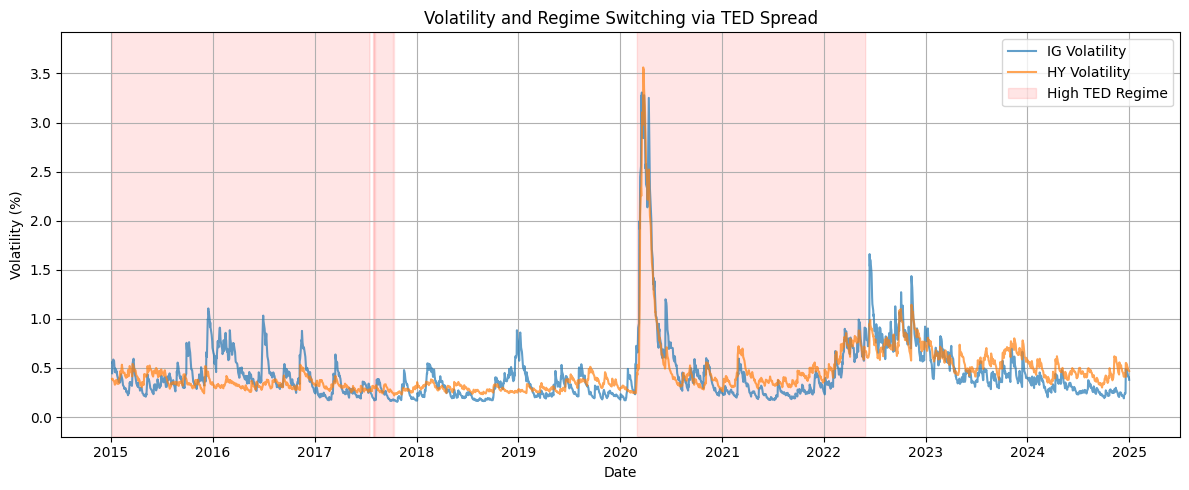

In [ ]:
# STEP 1: Install required packages
!pip install yfinance arch statsmodels --quiet

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt

# STEP 3: Download credit ETF prices
etf_data = yf.download(['LQD', 'HYG'], start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
print("ETF data rows:", len(etf_data))

returns = np.log(etf_data).diff().dropna()
returns.columns = ['CDX_IG_ret', 'CDX_HY_ret']
print("Returns rows:", len(returns))

# STEP 4: Download IRX (13-week T-bill rate)
irx_data = yf.download('^IRX', start='2015-01-01', end='2025-01-01', auto_adjust=True)
print("IRX data rows:", len(irx_data))

irx_series = irx_data['Close']

# STEP 5: Create TED spread proxy (assume fixed unsecured rate of 2.5%)
ted_series = (0.025 - irx_series).copy()
ted_series.name = 'TED'
print("TED series rows:", len(ted_series))

# STEP 6: Align indexes and merge
common_index = returns.index.intersection(ted_series.index)
returns = returns.loc[common_index]
ted_series = ted_series.loc[common_index]
df = returns.copy()
df['TED'] = ted_series
print("Merged df rows:", len(df))

# STEP 7: Check for empty input
ig_input = df['CDX_IG_ret'] * 100
hy_input = df['CDX_HY_ret'] * 100

if ig_input.dropna().empty or hy_input.dropna().empty:
    print("IG input empty:", ig_input.dropna().empty)
    print("HY input empty:", hy_input.dropna().empty)
    raise ValueError("GARCH input series is empty. Check data merging and availability.")

# STEP 8: Fit GARCH models
ig_model = arch_model(ig_input, vol='Garch', p=1, q=1)
hy_model = arch_model(hy_input, vol='Garch', p=1, q=1)

ig_res = ig_model.fit(disp='off')
hy_res = hy_model.fit(disp='off')

# STEP 9: Add volatilities
df['IG_vol'] = ig_res.conditional_volatility
df['HY_vol'] = hy_res.conditional_volatility

# STEP 10: Rolling correlation
df['rolling_corr'] = df['CDX_IG_ret'].rolling(window=60).corr(df['CDX_HY_ret'])

# STEP 11: Regime classification
df['regime'] = (df['TED'] > df['TED'].median()).astype(int)

# STEP 12: Plot
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['IG_vol'], label='IG Volatility', alpha=0.7)
plt.plot(df.index, df['HY_vol'], label='HY Volatility', alpha=0.7)
plt.fill_between(df.index, 0, 1, where=df['regime']==1, color='red', alpha=0.1,
                 transform=plt.gca().get_xaxis_transform(), label='High TED Regime')
plt.title('Volatility and Regime Switching via TED Spread')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Define crisis periods
crisis_windows = {
    'Aug 2007 Quant Crisis': ('2007-08-01', '2007-08-31'),
    '2008 GFC': ('2008-09-01', '2008-10-31'),
    'Mar 2020 COVID Crash': ('2020-02-20', '2020-04-07')
}

# Analyze each window
for label, (start, end) in crisis_windows.items():
    window_df = df.loc[start:end]
    if window_df.empty:
        print(f"{label}: No data available in this window.")
        continue

    print(f"\n=== {label} ===")
    print(f"Window size: {len(window_df)} days")
    print(f"Regime breakdown: {window_df['regime'].value_counts().to_dict()}")
    print(f"Mean IG Vol: {window_df['IG_vol'].mean():.4f}")
    print(f"Mean HY Vol: {window_df['HY_vol'].mean():.4f}")
    print(f"Mean Corr: {window_df['rolling_corr'].mean():.4f}")

Aug 2007 Quant Crisis: No data available in this window.
2008 GFC: No data available in this window.

=== Mar 2020 COVID Crash ===
Window size: 34 days
Regime breakdown: {1: 26, 0: 8}
Mean IG Vol: 1.8954
Mean HY Vol: 1.7452
Mean Corr: 0.3066


In [ ]:
# Define thresholds for volatility and correlation spikes
vol_thresh = df['IG_vol'].quantile(0.90)
corr_thresh = df['rolling_corr'].quantile(0.10)  # unusually low correlation

# Identify regime switch dates
regime_switch_dates = df[df['regime'] == 1].index

# Initialize counters
lead_times = []
false_positives = 0

for date in regime_switch_dates:
    future_window = df.loc[date:].head(10)  # look ahead 10 days
    vol_spike = (future_window['IG_vol'] > vol_thresh).any()
    corr_break = (future_window['rolling_corr'] < corr_thresh).any()

    if vol_spike or corr_break:
        lead_times.append((future_window.index[0] - date).days)
    else:
        false_positives += 1

# Report metrics
print(f"Average lead time: {np.mean(lead_times):.2f} days")
print(f"False positives: {false_positives} out of {len(regime_switch_dates)} regime switches")

Average lead time: 0.00 days
False positives: 834 out of 1256 regime switches


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=df.index, y=df['TED'], name='TED Spread', line=dict(color='red')))
fig.add_trace(go.Scatter(x=df.index, y=df['IG_vol'], name='IG Volatility', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=df.index, y=df['rolling_corr'], name='Rolling Correlation', line=dict(color='green')))

fig.update_layout(
    title='Risk Cascade: TED → Volatility → Correlation',
    xaxis_title='Date',
    yaxis_title='Value',
    legend=dict(x=0.01, y=0.99),
    template='plotly_white'
)

fig.show()



In [ ]:
# STEP 1: Define thresholds for spikes
vol_thresh = df['IG_vol'].quantile(0.90)
corr_thresh = df['rolling_corr'].quantile(0.10)  # unusually low correlation

# STEP 2: Identify regime switch dates
regime_switch_dates = df[df['regime'] == 1].index

# STEP 3: Initialize counters
lead_times = []
false_positives = 0

# STEP 4: Loop through regime switches
for date in regime_switch_dates:
    future_window = df.loc[date:].head(10)  # look ahead 10 days

    # Find first spike in volatility or correlation
    spike_dates = future_window[
        (future_window['IG_vol'] > vol_thresh) |
        (future_window['rolling_corr'] < corr_thresh)
    ].index

    if not spike_dates.empty:
        lead_time = (spike_dates[0] - date).days
        lead_times.append(lead_time)
    else:
        false_positives += 1

# STEP 5: Report metrics
print("=== Crisis Prediction Accuracy ===")
print(f"Total regime switches: {len(regime_switch_dates)}")
print(f"False positives: {false_positives}")
print(f"Average lead time: {np.mean(lead_times):.2f} days")
print(f"Median lead time: {np.median(lead_times):.2f} days")
print(f"Max lead time: {np.max(lead_times)} days")

# STEP 6: Interactive visualization of risk cascade
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=df.index, y=df['TED'], name='TED Spread', line=dict(color='red')))
fig.add_trace(go.Scatter(x=df.index, y=df['IG_vol'], name='IG Volatility', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=df.index, y=df['rolling_corr'], name='Rolling Correlation', line=dict(color='green')))

fig.update_layout(
    title='Risk Cascade: TED → Volatility → Correlation',
    xaxis_title='Date',
    yaxis_title='Value',
    legend=dict(x=0.01, y=0.99),
    template='plotly_white',
    height=500
)

fig.show()

=== Crisis Prediction Accuracy ===
Total regime switches: 1256
False positives: 834
Average lead time: 1.93 days
Median lead time: 0.00 days
Max lead time: 14 days
